# 02.1 — Red neuronal

Este notebook toma el mismo dataset y split temporal usado en `02_model.ipynb` (LightGBM/XGBoost/CatBoost), prepara los datos para una red neuronal (numéricas escaladas, categóricas como índices enteros para `nn.Embedding`, target `log1p` + estandarizado) y entrena/evalúa la red **en la misma corrida**, sin persistir nada a disco.

Pensado para subir a **Google Colab**: detecta el entorno y, si no encuentra el parquet localmente, pide subirlo (`files.upload()`). No depende de los paquetes `src`/`config` del repo — es autocontenido. Para entrenar más rápido, activá GPU en Colab (Entorno de ejecución → Cambiar tipo de entorno → GPU).

In [ ]:
!pip install torchviz torchinfo

In [1]:
import sys
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f"Running in Colab: {IN_COLAB}")

Running in Colab: True


In [2]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)

## Datos

Mismo nivel de agregación que `02_model.ipynb`: `level_09_daily_store_dept`.

In [3]:
LEVEL = "level_09_daily_store_dept"
DATA_FILENAME = f"dataset_{LEVEL}.parquet"

if IN_COLAB:
    data_path = Path(f"/content/{DATA_FILENAME}")
    if not data_path.exists():
        from google.colab import files
        print(f"Subi {DATA_FILENAME} (podés arrastrarlo a la ventana que se abre):")
        uploaded = files.upload()
        if DATA_FILENAME in uploaded:
            data_path.write_bytes(uploaded[DATA_FILENAME])
        else:
            raise FileNotFoundError(
                f"No se subió {DATA_FILENAME}. Verificá el nombre del archivo e intentá de nuevo."
            )
else:
    data_path = Path(f"../data/datasets/{DATA_FILENAME}")

df = pd.read_parquet(data_path)
df = df.sort_values("date").reset_index(drop=True)

print(df.shape)
df.head()

Subi dataset_level_09_daily_store_dept.parquet (podés arrastrarlo a la ventana que se abre):


Saving dataset_level_09_daily_store_dept.parquet to dataset_level_09_daily_store_dept.parquet
(135870, 115)


,agg_id,item_id,dept_id,cat_id,store_id,state_id,date,sales,gross_sales,avg_sell_price,price_lag_7,price_change,price_vs_mean,has_event,has_event_2,snap,event_name_1,event_type_1,event_name_2,event_type_2,year,month,day,dayofweek,weekofyear,is_weekend,cum7,cum14,cum21,cum28,cum35,cum42,cum365,price_vs_max,days_since_release,days_since_event,days_to_event,days_to_closure,event_type_1_enc,event_type_2_enc,quarter,is_month_start,is_month_end,is_store_closed,dow_sin,dow_cos,month_sin,month_cos,doy_sin,doy_cos,price_volatility,days_since_thanksgiving,days_to_thanksgiving,days_since_newyear,days_to_newyear,zero_streak,pct_zero_28,pct_zero_90,adi_expanding,cv2_90,is_likely_stockout,lag1,lag2,lag3,lag7,lag14,lag21,lag28,lag35,lag42,lag56,lag91,lag182,lag364,rolling_mean_lag7_window_size7,rolling_std_lag7_window_size7,rolling_min_lag7_window_size7,rolling_max_lag7_window_size7,rolling_mean_lag7_window_size14,rolling_std_lag7_window_size14,rolling_min_lag7_window_size14,rolling_max_lag7_window_size14,rolling_mean_lag28_window_size7,rolling_std_lag28_window_size7,rolling_min_lag28_window_size7,rolling_max_lag28_window_size7,rolling_mean_lag28_window_size28,rolling_std_lag28_window_size28,rolling_min_lag28_window_size28,rolling_max_lag28_window_size28,rolling_mean_lag28_window_size91,rolling_std_lag28_window_size91,rolling_min_lag28_window_size91,rolling_max_lag28_window_size91,rolling_mean_lag28_window_size7_truediv_rolling_mean_lag28_window_size28,rolling_mean_lag91_window_size28,rolling_std_lag91_window_size28,rolling_min_lag91_window_size28,rolling_max_lag91_window_size28,rolling_mean_lag91_window_size91,rolling_std_lag91_window_size91,rolling_min_lag91_window_size91,rolling_max_lag91_window_size91,expanding_mean_lag91,rolling_mean_lag364_window_size28,rolling_std_lag364_window_size28,rolling_min_lag364_window_size28,rolling_max_lag364_window_size28,rolling_mean_lag364_window_size91,rolling_std_lag364_window_size91,rolling_min_lag364_window_size91,rolling_max_lag364_window_size91,seasonal_rolling_mean_lag364_season_length7_window_size8,rolling_mean_lag365_window_size28,rolling_mean_lag365_window_size91
0,FOODS_1_FOODS_CA_1_CA,TOTAL,FOODS_1,FOODS,CA_1,CA,2011-01-29,297.0,681.179993,2.293535,NaN,NaN,0.991603,0,0,0,None,None,None,None,2011,1,29,5,4,1,1533.0,3305.0,5047.0,6652.0,8373.0,10069.0,75935.0,1.0,0,NaN,8.0,NaN,0,0,1,0,0,0,-0.974928,-0.222521,0.0,1.0,0.463258,0.886223,NaN,NaN,299.0,NaN,337.0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,HOUSEHOLD_1_HOUSEHOLD_CA_1_CA,TOTAL,HOUSEHOLD_1,HOUSEHOLD,CA_1,CA,2011-01-29,361.0,1409.290039,3.903850,NaN,NaN,1.002209,0,0,0,None,None,None,None,2011,1,29,5,4,1,2143.0,4003.0,6065.0,8223.0,10286.0,12291.0,123596.0,1.0,0,NaN,8.0,NaN,0,0,1,0,0,0,-0.974928,-0.222521,0.0,1.0,0.463258,0.886223,NaN,NaN,299.0,NaN,337.0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,FOODS_2_FOODS_TX_1_TX,TOTAL,FOODS_2,FOODS,TX_1,TX,2011-01-29,390.0,1193.359985,3.059897,NaN,NaN,0.933859,0,0,0,None,None,None,None,2011,1,29,5,4,1,2659.0,5183.0,7548.0,9379.0,11639.0,14332.0,124580.0,1.0,0,NaN,8.0,NaN,0,0,1,0,0,0,-0.974928,-0.222521,0.0,1.0,0.463258,0.886223,NaN,NaN,299.0,NaN,337.0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,HOUSEHOLD_1_HOUSEHOLD_CA_2_CA,TOTAL,HOUSEHOLD_1,HOUSEHOLD,CA_2,CA,2011-01-29,529.0,2115.379883,3.998828,NaN,NaN,1.026361,0,0,0,None,None,None,None,2011,1,29,5,4,1,2388.0,4869.0,7210.0,9707.0,11927.0,14439.0,145585.0,1.0,0,NaN,8.0,NaN

## Variables

Mismas columnas leaky/id/categóricas que en `02_model.ipynb`, para que ambos notebooks (árboles vs. red neuronal) comparen features en igualdad de condiciones.

In [4]:
TARGET = "sales"

ID_COLS = ["agg_id", "date"]
CUM_COLS = [c for c in df.columns if c.startswith("cum") and c[3:].isdigit()]
LEAKY_COLS = ["gross_sales"] + CUM_COLS

FEATURES = [c for c in df.columns if c not in ID_COLS + LEAKY_COLS + [TARGET]]

CATEGORICAL_FEATURES = [
    "item_id",
    "dept_id",
    "cat_id",
    "store_id",
    "state_id",
    "event_name_1",
    "event_type_1",
    "event_name_2",
    "event_type_2",
]

NUMERICAL_FEATURES = [c for c in FEATURES if c not in CATEGORICAL_FEATURES]

FEATURES = CATEGORICAL_FEATURES + NUMERICAL_FEATURES

print(f"Features: {len(FEATURES)} ({len(CATEGORICAL_FEATURES)} categoricas, {len(NUMERICAL_FEATURES)} numericas)")

Features: 104 (9 categoricas, 95 numericas)


## Split temporal

Misma lógica que `src/data/split.py::date_split` (reimplementada acá para que el notebook no dependa del paquete `src` en Colab): últimos `TEST_DAYS` como test, los `VALID_DAYS` anteriores como validación, el resto como train.

In [5]:
def date_split(df, valid_days, test_days, date_col="date"):
    first_date = df[date_col].min()
    last_date = df[date_col].max()
    test_start = last_date - pd.DateOffset(days=test_days)
    valid_start = test_start - pd.DateOffset(days=valid_days)

    train = df[df[date_col] < valid_start].copy()
    valid = df[(df[date_col] >= valid_start) & (df[date_col] < test_start)].copy()
    test = df[df[date_col] >= test_start].copy()

    return train, valid, test, first_date, last_date, valid_start, test_start


TEST_DAYS = 28
VALID_DAYS = 365

train, valid, test, first_date, last_date, valid_start, test_start = date_split(
    df, valid_days=VALID_DAYS, test_days=TEST_DAYS
)

print(f"Train : {first_date:%Y-%m-%d} to {valid_start:%Y-%m-%d} ({len(train):,} filas)")
print(f"Valid : {valid_start:%Y-%m-%d} to {test_start:%Y-%m-%d} ({len(valid):,} filas)")
print(f"Test  : {test_start:%Y-%m-%d} to {last_date:%Y-%m-%d} ({len(test):,} filas)")

Train : 2011-01-29 to 2015-04-25 (108,290 filas)
Valid : 2015-04-25 to 2016-04-24 (25,550 filas)
Test  : 2016-04-24 to 2016-05-22 (2,030 filas)


In [6]:
X_train = train[FEATURES].copy()
X_valid = valid[FEATURES].copy()
X_test = test[FEATURES].copy()

y_train = train[TARGET].copy()
y_valid = valid[TARGET].copy()
y_test = test[TARGET].copy()

## Categóricas → índices enteros

Las categorías se fijan sobre el dataset **completo** (train+valid+test), igual que hace `build_feature_matrices` para los árboles: evita que un split tenga categorías que otro no vio. Acá además:

- Los NaN (p. ej. días sin evento en `event_name_1/2`) se tratan como una categoría propia `"__MISSING__"` en vez de descartarse.
- El código `0` se reserva para "desconocido/missing"; las categorías reales arrancan en `1`. Esto es la convención habitual para `nn.Embedding` (podés usar `padding_idx=0` si querés que esa fila no aporte gradiente).
- `cardinalities` guarda, por columna, cuántos índices distintos existen — es el `num_embeddings` de cada `nn.Embedding`.

In [7]:
cat_categories = {}
cardinalities = {}

for col in CATEGORICAL_FEATURES:
    categories = df[col].fillna("__MISSING__").astype(str).unique()
    categories = sorted(categories)
    cat_categories[col] = categories
    cardinalities[col] = len(categories) + 1  # +1 por el indice 0 reservado

    mapping = {cat: i + 1 for i, cat in enumerate(categories)}

    for X in (X_train, X_valid, X_test):
        X[col] = X[col].fillna("__MISSING__").astype(str).map(mapping).fillna(0).astype("int64")

cardinalities

{'item_id': 2,
 'dept_id': 8,
 'cat_id': 4,
 'store_id': 11,
 'state_id': 4,
 'event_name_1': 32,
 'event_type_1': 6,
 'event_name_2': 6,
 'event_type_2': 4}

## Numéricas → imputación + escalado

Varias features de lag/rolling tienen NaN por definición (ventana no disponible al inicio de cada serie). Se imputan con la **mediana de train** (no de todo el dataset, para no filtrar información de valid/test) y luego se escala con `StandardScaler` fiteado también solo sobre train.

In [8]:
train_medians = X_train[NUMERICAL_FEATURES].median()

for X in (X_train, X_valid, X_test):
    X[NUMERICAL_FEATURES] = X[NUMERICAL_FEATURES].fillna(train_medians)

scaler = StandardScaler()
X_train[NUMERICAL_FEATURES] = scaler.fit_transform(X_train[NUMERICAL_FEATURES])
X_valid[NUMERICAL_FEATURES] = scaler.transform(X_valid[NUMERICAL_FEATURES])
X_test[NUMERICAL_FEATURES] = scaler.transform(X_test[NUMERICAL_FEATURES])

X_train[NUMERICAL_FEATURES].describe().T[["mean", "std", "min", "max"]].head(10)

,mean,std,min,max
avg_sell_price,3.254494e-17,1.000005,-2.895165,7.374690
price_lag_7,1.968444e-16,1.000005,-2.901265,7.395110
price_change,1.745354e-17,1.000005,-4.116023,77.173999
price_vs_mean,-3.149511e-17,1.000005,-5.751252,12.355798
has_event,-2.887051e-17,1.000005,-0.297775,3.358240
has_event_2,1.574755e-18,1.000005,-0.050915,19.640519
snap,3.044527e-17,1.000005,-0.701287,1.425950
year,8.202166e-14,1.000005,-1.372067,1.835470
month,1.091830e-16,1.000005,-1.537963,1.641665
day,7.558826e-17,1.000005,-1.671419,1.741877


## Target

`sales` tiene una distribución muy sesgada (muchos ceros, cola larga). Se aplica `log1p` antes de estandarizar — mejora la estabilidad del entrenamiento de la red — y se guarda el `target_scaler` para poder invertir la transformación sobre las predicciones (`np.expm1(scaler.inverse_transform(pred))`).

In [9]:
y_train_log = np.log1p(y_train.to_numpy(dtype="float64")).reshape(-1, 1)
y_valid_log = np.log1p(y_valid.to_numpy(dtype="float64")).reshape(-1, 1)
y_test_log = np.log1p(y_test.to_numpy(dtype="float64")).reshape(-1, 1)

target_scaler = StandardScaler()
y_train_scaled = target_scaler.fit_transform(y_train_log).ravel()
y_valid_scaled = target_scaler.transform(y_valid_log).ravel()
y_test_scaled = target_scaler.transform(y_test_log).ravel()

y_train_scaled[:5], y_train.iloc[:5].to_numpy()

(array([0.1815145 , 0.32605941, 0.383315  , 0.60930308, 0.30524663]),
 array([297., 361., 390., 529., 351.], dtype=float32))

## Sanity check

Arma los arrays finales (numéricas + categóricas por separado, como espera una red con `nn.Embedding` por columna categórica) y confirma que las formas cuadran antes de exportar.

In [10]:
X_train_num = X_train[NUMERICAL_FEATURES].to_numpy(dtype="float32")
X_valid_num = X_valid[NUMERICAL_FEATURES].to_numpy(dtype="float32")
X_test_num = X_test[NUMERICAL_FEATURES].to_numpy(dtype="float32")

X_train_cat = X_train[CATEGORICAL_FEATURES].to_numpy(dtype="int64")
X_valid_cat = X_valid[CATEGORICAL_FEATURES].to_numpy(dtype="int64")
X_test_cat = X_test[CATEGORICAL_FEATURES].to_numpy(dtype="int64")

assert not np.isnan(X_train_num).any()
assert not np.isnan(X_valid_num).any()
assert not np.isnan(X_test_num).any()

print("num:", X_train_num.shape, X_valid_num.shape, X_test_num.shape)
print("cat:", X_train_cat.shape, X_valid_cat.shape, X_test_cat.shape)
print("y  :", y_train_scaled.shape, y_valid_scaled.shape, y_test_scaled.shape)

num: (108290, 95) (25550, 95) (2030, 95)
cat: (108290, 9) (25550, 9) (2030, 9)
y  : (108290,) (25550,) (2030,)


## Red neuronal (PyTorch)

Arquitectura tabular estándar: un `nn.Embedding` por columna categórica (dimensión = heurística `min(50, (cardinalidad+1)//2)`) concatenado con las numéricas ya escaladas, seguido de un MLP con `BatchNorm` + `Dropout`. Entrena sobre `y` transformado (`log1p` + estandarizado) con `MSELoss`, y usa GPU automáticamente si Colab la tiene habilitada (Entorno de ejecución → Cambiar tipo de entorno → GPU).

In [11]:
# Colab ya trae torch instalado; esta celda solo importa.
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [12]:
class TabularDataset(Dataset):
    def __init__(self, X_num, X_cat, y):
        self.X_num = torch.from_numpy(X_num)
        self.X_cat = torch.from_numpy(X_cat)
        self.y = torch.from_numpy(y.astype("float32"))

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_num[idx], self.X_cat[idx], self.y[idx]


BATCH_SIZE = 1024

train_ds = TabularDataset(X_train_num, X_train_cat, y_train_scaled)
valid_ds = TabularDataset(X_valid_num, X_valid_cat, y_valid_scaled)
test_ds = TabularDataset(X_test_num, X_test_cat, y_test_scaled)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

In [13]:
class TabularNN(nn.Module):
    def __init__(self, cardinalities, categorical_features, n_numerical, hidden_dims=(256, 128, 64), dropout=0.2):
        super().__init__()
        self.categorical_features = categorical_features

        self.embeddings = nn.ModuleList([
            nn.Embedding(cardinalities[col], min(50, (cardinalities[col] + 1) // 2), padding_idx=0)
            for col in categorical_features
        ])
        emb_dim_total = sum(e.embedding_dim for e in self.embeddings)

        self.num_bn = nn.BatchNorm1d(n_numerical)

        layers = []
        in_dim = emb_dim_total + n_numerical
        for h in hidden_dims:
            layers += [nn.Linear(in_dim, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.mlp = nn.Sequential(*layers)

    def forward(self, x_num, x_cat):
        embs = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
        x = torch.cat(embs + [self.num_bn(x_num)], dim=1)
        return self.mlp(x).squeeze(1)


model = TabularNN(cardinalities, CATEGORICAL_FEATURES, n_numerical=len(NUMERICAL_FEATURES)).to(device)
print(model)
print(f"Parametros entrenables: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

TabularNN(
  (embeddings): ModuleList(
    (0): Embedding(2, 1, padding_idx=0)
    (1): Embedding(8, 4, padding_idx=0)
    (2): Embedding(4, 2, padding_idx=0)
    (3): Embedding(11, 6, padding_idx=0)
    (4): Embedding(4, 2, padding_idx=0)
    (5): Embedding(32, 16, padding_idx=0)
    (6-7): 2 x Embedding(6, 3, padding_idx=0)
    (8): Embedding(4, 2, padding_idx=0)
  )
  (num_bn): BatchNorm1d(95, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (mlp): Sequential(
    (0): Linear(in_features=134, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, mome

### Entrenamiento

Early stopping sobre la pérdida de validación (MSE en escala `log1p` + estandarizada): si no mejora en `PATIENCE` épocas consecutivas, corta y se queda con los pesos de la mejor época.

In [14]:
import copy
import time

EPOCHS = 100
PATIENCE = 10
LR = 1e-3

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)
loss_fn = nn.MSELoss()

history = {"train_loss": [], "valid_loss": []}
best_valid_loss = float("inf")
best_state = None
epochs_no_improve = 0

t0 = time.perf_counter()
for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0
    for x_num, x_cat, y in train_loader:
        x_num, x_cat, y = x_num.to(device), x_cat.to(device), y.to(device)

        optimizer.zero_grad()
        y_pred = model(x_num, x_cat)
        loss = loss_fn(y_pred, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * len(y)
    train_loss /= len(train_ds)

    model.eval()
    valid_loss = 0.0
    with torch.no_grad():
        for x_num, x_cat, y in valid_loader:
            x_num, x_cat, y = x_num.to(device), x_cat.to(device), y.to(device)
            y_pred = model(x_num, x_cat)
            valid_loss += loss_fn(y_pred, y).item() * len(y)
    valid_loss /= len(valid_ds)

    scheduler.step(valid_loss)
    history["train_loss"].append(train_loss)
    history["valid_loss"].append(valid_loss)

    improved = valid_loss < best_valid_loss - 1e-5
    if improved:
        best_valid_loss = valid_loss
        best_state = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    print(f"Epoch {epoch:3d} | train_loss {train_loss:.4f} | valid_loss {valid_loss:.4f}"
          f"{'  *' if improved else ''}")

    if epochs_no_improve >= PATIENCE:
        print(f"Early stopping en epoch {epoch} (mejor valid_loss: {best_valid_loss:.4f})")
        break

total_fit_time = time.perf_counter() - t0
model.load_state_dict(best_state)
print(f"Tiempo total de entrenamiento: {total_fit_time:.1f}s")

Epoch   1 | train_loss 0.1410 | valid_loss 0.0273  *
Epoch   2 | train_loss 0.0708 | valid_loss 0.0250  *
Epoch   3 | train_loss 0.0601 | valid_loss 0.0237  *
Epoch   4 | train_loss 0.0551 | valid_loss 0.0215  *
Epoch   5 | train_loss 0.0511 | valid_loss 0.0228
Epoch   6 | train_loss 0.0493 | valid_loss 0.0200  *
Epoch   7 | train_loss 0.0468 | valid_loss 0.0225
Epoch   8 | train_loss 0.0460 | valid_loss 0.0222
Epoch   9 | train_loss 0.0445 | valid_loss 0.0204
Epoch  10 | train_loss 0.0435 | valid_loss 0.0246
Epoch  11 | train_loss 0.0425 | valid_loss 0.0217
Epoch  12 | train_loss 0.0414 | valid_loss 0.0219
Epoch  13 | train_loss 0.0414 | valid_loss 0.0213
Epoch  14 | train_loss 0.0412 | valid_loss 0.0214
Epoch  15 | train_loss 0.0404 | valid_loss 0.0205
Epoch  16 | train_loss 0.0401 | valid_loss 0.0211
Early stopping en epoch 16 (mejor valid_loss: 0.0200)
Tiempo total de entrenamiento: 28.2s


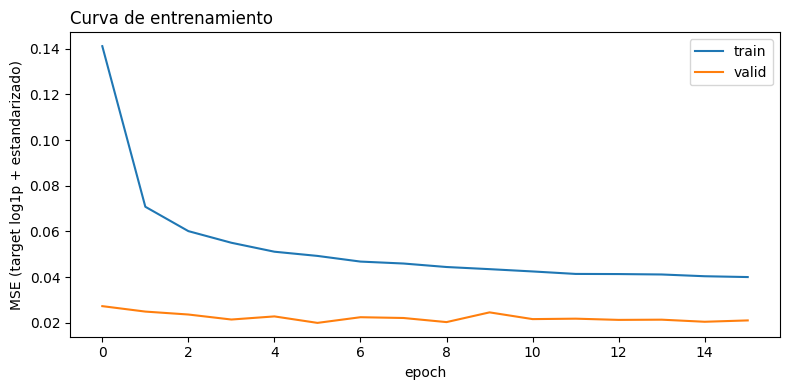

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history["train_loss"], label="train")
ax.plot(history["valid_loss"], label="valid")
ax.set_xlabel("epoch")
ax.set_ylabel("MSE (target log1p + estandarizado)")
ax.set_title("Curva de entrenamiento", loc="left")
ax.legend()
plt.tight_layout()
plt.show()

In [18]:
from torchviz import make_dot

x_num_sample = X_valid_num[:1]  # ajusta a tus inputs reales
x_cat_sample = X_valid_cat[:1]
y_sample = model(x_num_sample, x_cat_sample)

dot = make_dot(y_sample, params=dict(model.named_parameters()))
dot.render("tabular_nn_graph", format="png")  # guarda como PNG

TypeError: embedding(): argument 'indices' (position 2) must be Tensor, not numpy.ndarray

## Evaluación

Se predice en la escala transformada y se invierte (`inverse_transform` del `target_scaler` + `expm1`) para calcular métricas en unidades reales de `sales`: WAPE, MAE y RMSE.

In [ ]:
def predict(loader):
    model.eval()
    preds = []
    with torch.no_grad():
        for x_num, x_cat, _ in loader:
            x_num, x_cat = x_num.to(device), x_cat.to(device)
            preds.append(model(x_num, x_cat).cpu().numpy())
    return np.concatenate(preds)


def inverse_target(y_scaled):
    y_log = target_scaler.inverse_transform(y_scaled.reshape(-1, 1)).ravel()
    return np.expm1(y_log)


def wape(y_true, y_pred):
    return np.abs(y_true - y_pred).sum() / np.abs(y_true).sum()


def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))


for name, loader, y_raw in [("Valid", valid_loader, y_valid.to_numpy()), ("Test", test_loader, y_test.to_numpy())]:
    y_pred_scaled = predict(loader)
    y_pred = inverse_target(y_pred_scaled)
    y_pred = np.clip(y_pred, 0, None)  # sales no puede ser negativo

    print(f"{name:5s} | WAPE {wape(y_raw, y_pred):.2%} | MAE {mae(y_raw, y_pred):.3f} | RMSE {rmse(y_raw, y_pred):.3f}")

## Resultado en formato comparable (`evaluate_predictions`)

Mismas métricas que `src/evaluation/metrics.py::evaluate_predictions` (WAPE, WRMSSE, MAE, RMSE, MAPE, SMAPE, bias, RMSLE, tracking signal, SPEC, MASE), calculadas sobre el set de **validación** para que el resultado sea comparable fila a fila con `model_results` de `02_model.ipynb`. Reimplementadas acá (no se importa `src` porque este notebook corre en Colab) pero replican exactamente la misma lógica: WRMSSE/SPEC/MASE ponderados por venta en $ de los últimos 28 días de train, y clip a 0 en `is_store_closed`.

In [ ]:
_SERIES_COL = "agg_id"
_PRICE_COL = "avg_sell_price"


def _bias(y_true, y_pred):
    return (y_pred - y_true).sum() / np.abs(y_true).sum()


def _smape(y_true, y_pred):
    denom = np.abs(y_true) + np.abs(y_pred) + 1e-8
    return np.mean(2 * np.abs(y_pred - y_true) / denom)


def _spec(y_true, y_pred, a1=0.75, a2=0.25):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    n = y_true.size
    cy = np.concatenate(([0.0], np.cumsum(y_true)))
    cf = np.concatenate(([0.0], np.cumsum(y_pred)))
    delta1 = cy[1:][:, None] - cf[1:][None, :]
    delta2 = cf[1:][:, None] - cy[1:][None, :]
    term = np.maximum(0.0, np.maximum(
        a1 * np.minimum(y_true[:, None], delta1),
        a2 * np.minimum(y_pred[:, None], delta2),
    ))
    i_idx = np.arange(1, n + 1)[:, None]
    t_idx = np.arange(1, n + 1)[None, :]
    weight = (t_idx - i_idx + 1).astype(float)
    mask = i_idx <= t_idx
    return float(np.sum(term * weight * mask) / n)


def _clip_closed_stores(valid_df, preds):
    preds = np.asarray(preds, dtype=float)
    if "is_store_closed" in valid_df.columns:
        preds = np.where(valid_df["is_store_closed"].to_numpy() == 1, 0.0, preds)
    return preds


def _compute_scales(train_df, group_col=_SERIES_COL):
    scales = {}
    for gid, sub in train_df.sort_values("date").groupby(group_col, sort=False):
        y = sub["sales"].to_numpy(dtype=float)
        nz = np.flatnonzero(y)
        if nz.size == 0:
            continue
        y = y[nz[0]:]
        if y.size < 2:
            continue
        scales[gid] = float(np.mean(np.diff(y) ** 2))
    return scales


def _compute_mae_scales(train_df, group_col=_SERIES_COL, m=1):
    scales = {}
    for gid, sub in train_df.sort_values("date").groupby(group_col, sort=False):
        y = sub["sales"].to_numpy(dtype=float)
        nz = np.flatnonzero(y)
        if nz.size == 0:
            continue
        y = y[nz[0]:]
        if y.size <= m:
            continue
        scales[gid] = float(np.mean(np.abs(y[m:] - y[:-m])))
    return scales


def _compute_weights(train_df, price_col=_PRICE_COL, group_col=_SERIES_COL, last_days=28):
    cutoff = train_df["date"].max() - pd.Timedelta(days=last_days)
    recent = train_df[train_df["date"] > cutoff]
    dollar = (recent["sales"] * recent[price_col]).groupby(recent[group_col]).sum()
    return dollar.to_dict()


def _weighted_avg(per_series, weights, group_col=_SERIES_COL):
    if not per_series:
        return float("nan")
    if weights is None:
        return float(np.mean(list(per_series.values())))
    w = {g: weights.get(g, 0.0) for g in per_series}
    total = sum(w.values())
    if total == 0:
        return float(np.mean(list(per_series.values())))
    return float(sum(per_series[g] * w[g] / total for g in per_series))


def _compute_wrmsse(train_df, valid_df, preds, group_col=_SERIES_COL, price_col=_PRICE_COL):
    if group_col not in valid_df.columns:
        return float("nan")
    valid_with_preds = valid_df[[group_col, "date", "sales"]].copy()
    valid_with_preds["forecast"] = _clip_closed_stores(valid_df, preds)
    scales = _compute_scales(train_df, group_col)
    weights = _compute_weights(train_df, price_col, group_col) if price_col in train_df.columns else None

    rmsse = {}
    for gid, sub in valid_with_preds.groupby(group_col, sort=False):
        scale = scales.get(gid)
        if not scale:
            continue
        num = np.mean((sub["sales"].to_numpy() - sub["forecast"].to_numpy()) ** 2)
        rmsse[gid] = float(np.sqrt(num / scale))
    return _weighted_avg(rmsse, weights, group_col)


def _compute_mase(train_df, valid_df, preds, group_col=_SERIES_COL, price_col=_PRICE_COL, m=1):
    if group_col not in valid_df.columns:
        return float("nan")
    valid_with_preds = valid_df[[group_col, "date", "sales"]].copy()
    valid_with_preds["forecast"] = _clip_closed_stores(valid_df, preds)
    scales = _compute_mae_scales(train_df, group_col, m=m)
    weights = _compute_weights(train_df, price_col, group_col) if price_col in train_df.columns else None

    mase_by_series = {}
    for gid, sub in valid_with_preds.groupby(group_col, sort=False):
        scale = scales.get(gid)
        if not scale:
            continue
        mae_i = np.mean(np.abs(sub["sales"].to_numpy() - sub["forecast"].to_numpy()))
        mase_by_series[gid] = float(mae_i / scale)
    return _weighted_avg(mase_by_series, weights, group_col)


def _compute_spec(train_df, valid_df, preds, group_col=_SERIES_COL, price_col=_PRICE_COL, a1=0.75, a2=0.25):
    if group_col not in valid_df.columns:
        return float("nan")
    valid_with_preds = valid_df[[group_col, "date", "sales"]].copy()
    valid_with_preds["forecast"] = _clip_closed_stores(valid_df, preds)
    weights = _compute_weights(train_df, price_col, group_col) if price_col in train_df.columns else None

    spec_by_series = {}
    for gid, sub in valid_with_preds.sort_values("date").groupby(group_col, sort=False):
        y_true = sub["sales"].to_numpy()
        if y_true.size == 0:
            continue
        spec_by_series[gid] = _spec(y_true, sub["forecast"].to_numpy(), a1=a1, a2=a2)
    return _weighted_avg(spec_by_series, weights, group_col)


def evaluate_predictions(train_df, valid_df, y_valid, y_pred_valid, name, fit_time=None, category=None):
    y_pred_valid = _clip_closed_stores(valid_df, y_pred_valid)
    y_valid = np.asarray(y_valid, dtype=float)
    y_pred_valid = np.asarray(y_pred_valid, dtype=float)
    return {
        "model": name,
        "category": category,
        "wape": float(wape(y_valid, y_pred_valid)),
        "wrmsse": _compute_wrmsse(train_df, valid_df, y_pred_valid),
        "mae": float(mae(y_valid, y_pred_valid)),
        "rmse": float(rmse(y_valid, y_pred_valid)),
        "mape": float(np.mean(np.abs(y_valid - y_pred_valid) / (np.abs(y_valid) + 1e-8))),
        "smape": float(_smape(y_valid, y_pred_valid)),
        "bias": float(_bias(y_valid, y_pred_valid)),
        "rmsle": float(np.sqrt(np.mean((np.log1p(np.clip(y_pred_valid, 0, None)) - np.log1p(np.clip(y_valid, 0, None))) ** 2))),
        "tracking_signal": float(np.sum(y_valid - y_pred_valid) / (np.mean(np.abs(y_valid - y_pred_valid)) or 1.0)),
        "spec": _compute_spec(train_df, valid_df, y_pred_valid),
        "mase": _compute_mase(train_df, valid_df, y_pred_valid),
        "fit_time": fit_time,
    }

In [ ]:
import json

y_pred_valid_scaled = predict(valid_loader)
y_pred_valid = np.clip(inverse_target(y_pred_valid_scaled), 0, None)

nn_result = evaluate_predictions(
    train, valid, y_valid.to_numpy(), y_pred_valid,
    name="Red neuronal (PyTorch)", fit_time=total_fit_time, category="Neural Network",
)
nn_result

Copiá el JSON de abajo y pegalo en `02_model.ipynb`, en la celda agregada para tal fin (justo antes de la sección "Resultados"): allí se lee y se agrega a `model_results` para que aparezca en la tabla comparativa junto a LightGBM/XGBoost/etc.

In [ ]:
print(json.dumps(nn_result, indent=2, ensure_ascii=False))

## Explicación del modelo (SHAP)

`TabularNN.forward` recibe dos tensores separados (`x_num` continuo, `x_cat` con índices enteros para los embeddings): los índices categóricos no son diferenciables, así que `GradientExplainer`/`DeepExplainer` no aplican directamente acá (dependen de gradientes respecto al input). En cambio se usa `shap.Explainer` con el algoritmo de permutación: trata a la red como caja negra (`X -> predicción de sales`), igual que se haría con cualquier modelo no diferenciable — más lento que un explainer basado en gradientes, pero válido para cualquier arquitectura.

Se arma una única matriz `[categóricas | numéricas]` (mismo orden que `FEATURES`) para que SHAP la trate como tabular estándar; adentro del wrapper se separan y castean de nuevo a los tipos que espera el modelo.

In [ ]:
try:
    import shap
except ImportError:
    import sys
    get_ipython().system(f"{sys.executable} -m pip install -q shap")
    import shap

N_CAT = len(CATEGORICAL_FEATURES)
FEATURE_NAMES_SHAP = CATEGORICAL_FEATURES + NUMERICAL_FEATURES

X_train_combined = np.concatenate([X_train_cat.astype("float32"), X_train_num], axis=1)
X_test_combined = np.concatenate([X_test_cat.astype("float32"), X_test_num], axis=1)


def model_predict_raw(X):
    """Wrapper caja-negra para SHAP: recibe [categoricas | numericas] y devuelve
    la prediccion en escala real de sales (invierte log1p + StandardScaler)."""
    X = np.asarray(X, dtype="float32")
    x_cat = np.round(X[:, :N_CAT]).astype("int64")
    x_num = X[:, N_CAT:].astype("float32")

    model.eval()
    with torch.no_grad():
        x_num_t = torch.from_numpy(x_num).to(device)
        x_cat_t = torch.from_numpy(x_cat).to(device)
        y_scaled = model(x_num_t, x_cat_t).cpu().numpy()

    return inverse_target(y_scaled)

In [ ]:
background = shap.sample(X_train_combined, 100, random_state=42)
X_shap = shap.sample(X_test_combined, 200, random_state=42)

explainer = shap.Explainer(model_predict_raw, background, feature_names=FEATURE_NAMES_SHAP)
shap_values = explainer(X_shap, max_evals=2 * len(FEATURE_NAMES_SHAP) + 1)

### Importancia global de features

In [ ]:
shap.plots.bar(shap_values, max_display=30)

In [ ]:
shap.plots.beeswarm(shap_values, max_display=30)

### Dependencia del feature más importante

In [ ]:
top_idx = np.argsort(-np.abs(shap_values.values).mean(axis=0))[0]
top_feature = FEATURE_NAMES_SHAP[top_idx]
print(f"Feature mas importante: {top_feature}")

shap.plots.scatter(shap_values[:, top_idx])